In [4]:
import numpy as np
import matplotlib.pyplot as plt

inp = r"train/train/NoisyLR/000001.npy"
out = r"train/train/GT/000001.npy"

inImg = np.load(inp)
outImg = np.load(out)



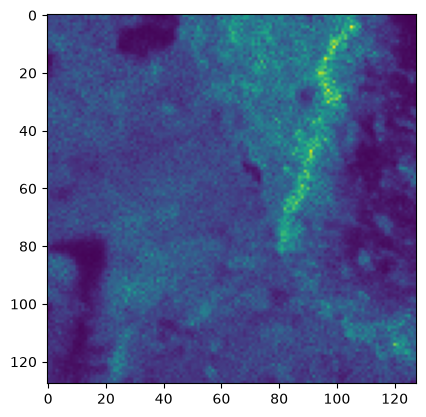

In [5]:
plt.imshow(inImg)

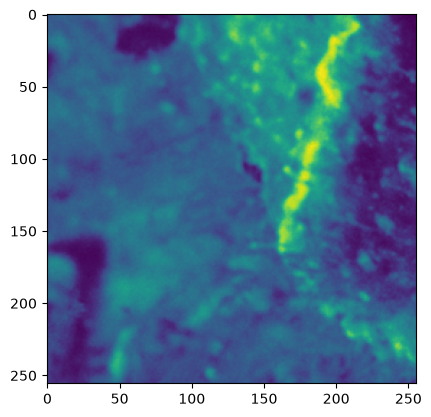

In [6]:
plt.imshow(outImg)

In [17]:
import shutil
from pathlib import Path


src = r"train/train/GT/00000"
dest  = r"dataset/gt"
fold = Path(dest)
fold.mkdir(parents = True, exist_ok=True)
for i in range(0, 10, 1):
    sr = src + str(i) + ".npy"
    try:
        shutil.move(sr, dest)    
    except: 
        continue


# shutil.move(src, dest)

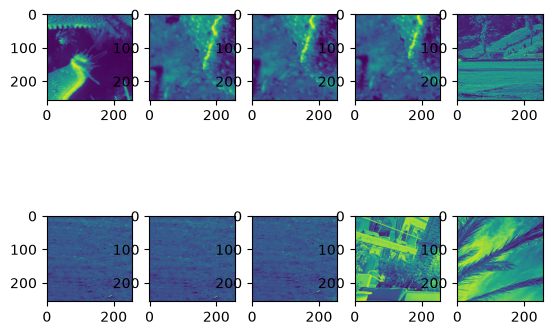

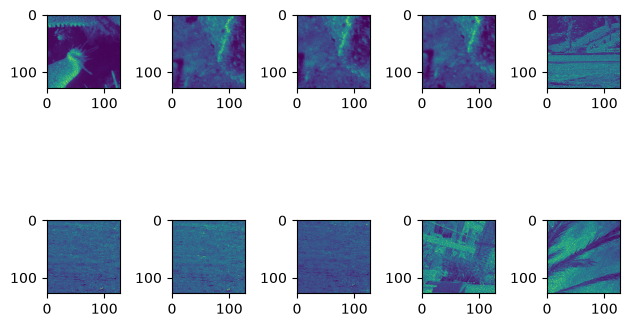

In [29]:
gt = r"dataset/gt/00000"
d_test = r"dataset/test/00000"

images_gt = []
images_test = []
for i in range(0, 10, 1):
    imgsrc_gt = gt + str(i) + ".npy"
    imgsrc_test = d_test + str(i) + ".npy"
    images_gt.append(np.load(imgsrc_gt))
    images_test.append(np.load(imgsrc_test))
    
fig1, axes1 = plt.subplots(2,5)
fig2, axes2 = plt.subplots(2,5)
for ax, img in zip(axes1.flat, images_gt):
    ax.imshow(img)

for ax, img in zip(axes2.flat, images_test):
    ax.imshow(img)
    
    
plt.tight_layout()
plt.show()

In [32]:
import numpy as np
from PIL import Image
from pathlib import Path

src = Path(r"dataset/test/")
dest = Path(r"dataset/gt/png/")
dest.mkdir(exist_ok=True)

for file in src.glob("*.npy"):
    img = np.load(file)

    if img.dtype != np.uint8:
        img = (img * 255).clip(0, 255).astype(np.uint8)

    Image.fromarray(img).save(dest / f"{file.stem}.png")